# Simulated observation data

This notebook generates a synthetic data cube containing a moving
point source, a varying background, detector sensitivity variations,
and counting noise. It writes `../data/tutorial_demo.fits` for the model
tutorials, containing the data cube, an observation mask, the detector
sensitivity map, and the fixed background component.

In [1]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['image.origin'] = 'lower'

In [2]:
import astropy.io.fits as fits
import numpy as np
import scipy.ndimage as ndimage

## Observation model

Create 128 frames of 32 x 32 pixels. Define a fixed additive background
(`const`) and a smoothly varying background level (`flux`). The detector
sensitivity map (`flat`) multiplies both `flux` and the point-source
signal when generating the data cube.

In [3]:
rng = np.random.default_rng(42)
nz, ny, nx = 128, 32, 32

flat = ndimage.gaussian_filter(rng.normal(1.0, 1e-2, size=(ny, nx)), sigma=1.0)
const = ndimage.zoom(rng.normal(1e4, 1e3, size=(8, 8)), 4)
flux = ndimage.gaussian_filter1d(
  rng.normal(1e5, 1e4, size=(nz, 1, 1)), sigma=8, axis=0
)

### Inspect the observation model

Display the fixed background and sensitivity pattern to check their
spatial structure.

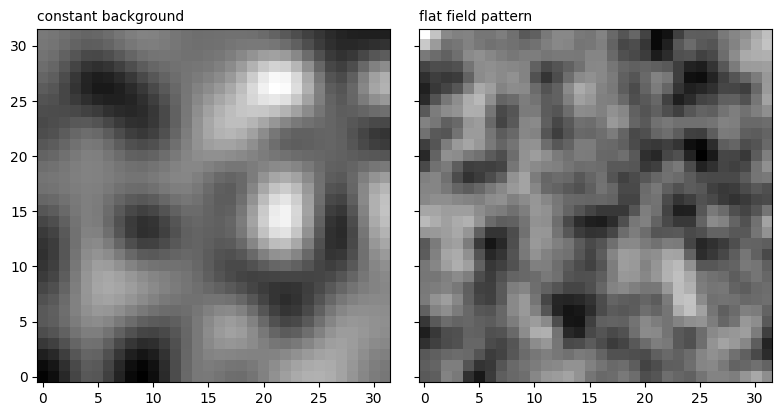

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

axes[0].imshow(const, cmap='gray')
axes[0].set_title('constant background', fontsize=10, loc='left')

axes[1].imshow(flat, cmap='gray')
axes[1].set_title('flat field pattern', fontsize=10, loc='left')

fig.tight_layout()
plt.show()

## Moving source template

Create a Gaussian point-source image with a width of 1.5 pixels in sigma. Define
its footprint using pixels above 10% of the peak, and an `offset` function
to shift either template across the detector.

In [5]:
one = np.zeros((ny, nx))
one[15, 15] = 1.0
star = ndimage.gaussian_filter(one, sigma=1.5)
disk = np.asarray(star > 0.1 * star.max()).astype(np.float64)


def offset(star, x, y):
  dx = 16.0 - x
  dy = 16.0 - y
  return ndimage.affine_transform(star, np.eye(2), offset=(dy, dx))

### Inspect the source

Compare the point-source intensity profile with its binary footprint.

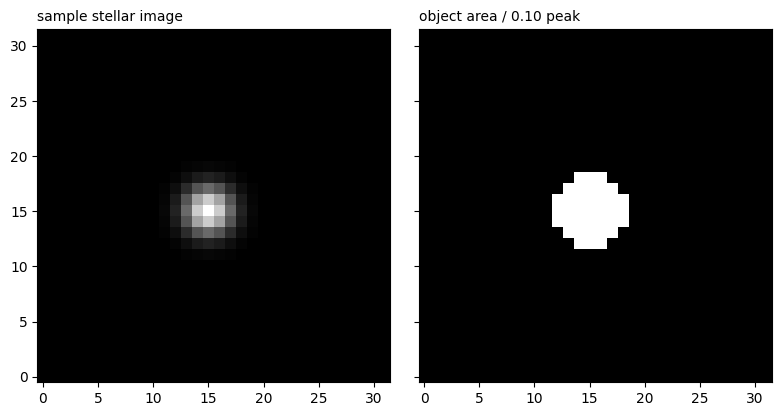

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

axes[0].imshow(star, cmap='gray')
axes[0].set_title('sample stellar image', fontsize=10, loc='left')

axes[1].imshow(disk, cmap='gray')
axes[1].set_title('object area / 0.10 peak', fontsize=10, loc='left')

fig.tight_layout()
plt.show()

## Generate the data cube and mask

Move the source along a straight path and combine it with the background.
Apply scaled Poisson noise to simulate counting fluctuations; `pscale`
controls the noise level. Build a matching mask with 1 in the source
footprint and 0 elsewhere.

In [ ]:
rng = np.random.default_rng(1)
data = np.zeros((nz, ny, nx))
mask = np.zeros((nz, ny, nx))
signal = 100.0
pscale = 100000.0
x = 5.0 + 20.0 * np.linspace(0, 1, nz)
y = 20.0 - 15.0 * np.linspace(0, 1, nz)

poisson = lambda x: rng.poisson(pscale * x) / pscale

for n in range(nz):
  data[n] = poisson(
    const + flat * (flux[n] + signal * offset(star, x[n], y[n]))
  )
  mask[n] = np.round(offset(disk, x[n], y[n])).astype(bool)

data = np.array(data)
mask = np.array(mask)

### Inspect the data cube

Display six frames at intervals of twenty frames to inspect source motion
and background variation.

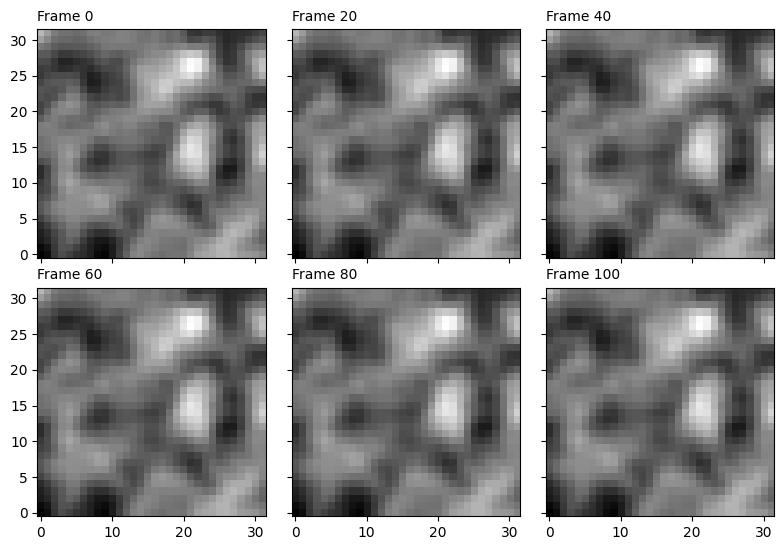

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(8, 5.5), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
  ax.imshow(data[n * 20], cmap='gray')
  ax.set_title(f'Frame {n * 20}', fontsize=10, loc='left')

fig.tight_layout()
plt.show()

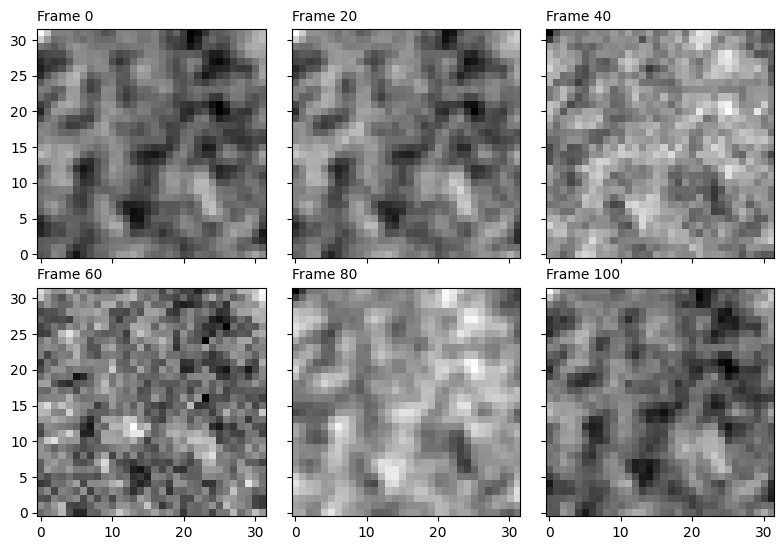

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(8, 5.5), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
  ax.imshow(data[n * 20] - data.mean(axis=0), cmap='gray')
  ax.set_title(f'Frame {n * 20}', fontsize=10, loc='left')

fig.tight_layout()
plt.show()

### Inspect the mask

Display the corresponding masks to check that the excluded region
follows the moving source.

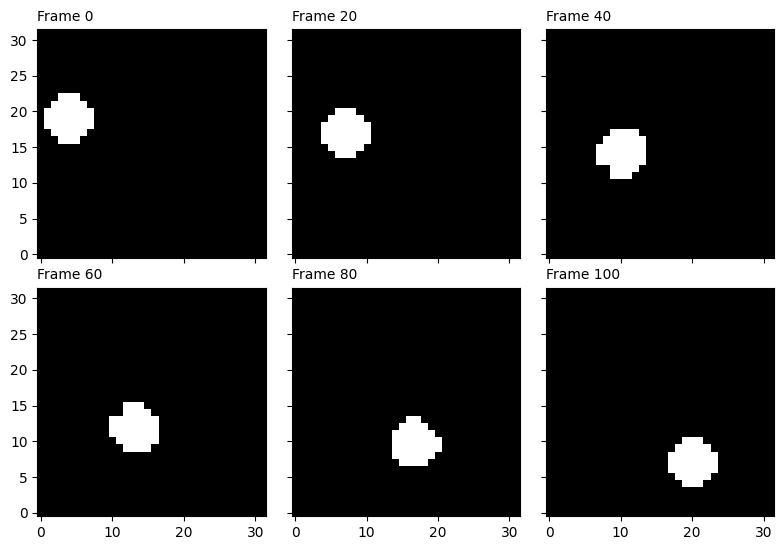

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(8, 5.5), sharex=True, sharey=True)

for n, ax in enumerate(axes.flatten()):
  ax.imshow(mask[n * 20], cmap='gray')
  ax.set_title(f'Frame {n * 20}', fontsize=10, loc='left')

fig.tight_layout()
plt.show()

## Assemble the FITS HDUs

Store the simulated data cube in the primary HDU. Add `MASK` (1 in
the source footprint, 0 elsewhere), `FLAT` (detector sensitivity),
and `CONST` (fixed additive background) as image extensions.
Display the HDU summary to check the file structure.

In [11]:
header = fits.Header()

header['SEED'] = 42

phdu = fits.PrimaryHDU(data=data, header=header)
mhdu = fits.ImageHDU(data=mask, name='MASK')
fhdu = fits.ImageHDU(data=flat, name='FLAT')
chdu = fits.ImageHDU(data=const, name='CONST')

hdul = fits.HDUList([phdu, mhdu, fhdu, chdu])
hdul.info()

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   (32, 32, 128)   float64   
  1  MASK          1 ImageHDU         9   (32, 32, 128)   float64   
  2  FLAT          1 ImageHDU         8   (32, 32)   float64   
  3  CONST         1 ImageHDU         8   (32, 32)   float64   


In [12]:
hdul.writeto('../data/tutorial_demo.fits', overwrite=True)